In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Cargamos TODAS las columnas
df_full = pd.read_csv('application_train.csv')
print(f"Shape: {df_full.shape}")
print(f"Columnas: {df_full.shape[1]}")
df_full.head(3)

Shape: (307511, 122)
Columnas: 122


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Sin nulos:         55 columnas
Nulos ≤20%:        17 columnas  ← candidatas prioritarias
Nulos 20-60%:      33 columnas  ← solo si aportan mucho
Nulos >60%:        17 columnas  ← descartar


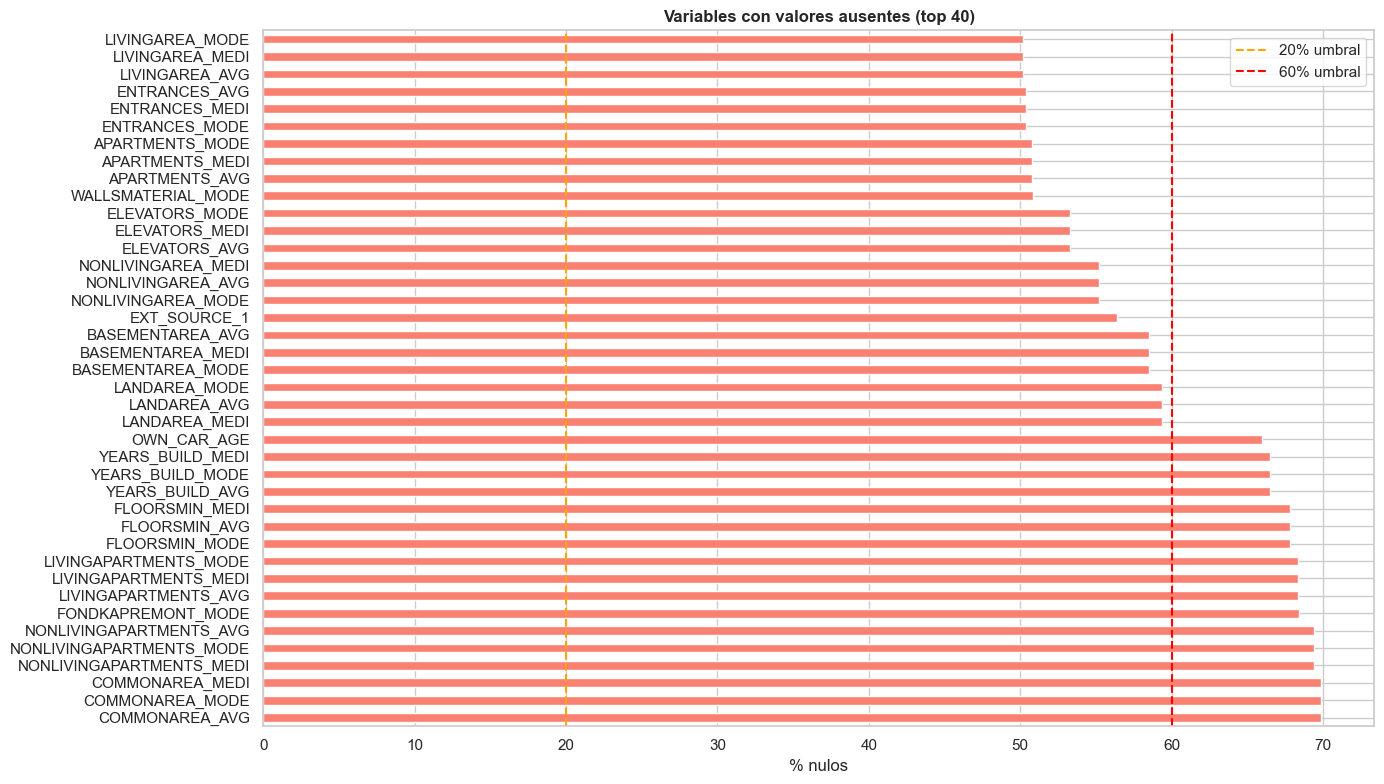

In [2]:
# CONTEO DE NULOS
# Porcentaje de nulos por columna, ordenado
na_pct = (df_full.isna().mean() * 100).sort_values(ascending=False)

# Clasificar por nivel de nulos
sin_nulos    = na_pct[na_pct == 0]
pocos_nulos  = na_pct[(na_pct > 0) & (na_pct <= 20)]
muchos_nulos = na_pct[(na_pct > 20) & (na_pct <= 60)]
demasiados   = na_pct[na_pct > 60]

print(f"Sin nulos:        {len(sin_nulos):>3} columnas")
print(f"Nulos ≤20%:       {len(pocos_nulos):>3} columnas  ← candidatas prioritarias")
print(f"Nulos 20-60%:     {len(muchos_nulos):>3} columnas  ← solo si aportan mucho")
print(f"Nulos >60%:       {len(demasiados):>3} columnas  ← descartar")

# Plot top 30 con más nulos
fig, ax = plt.subplots(figsize=(14, 8))
na_pct[na_pct > 0][:40].plot.barh(ax=ax, color='salmon')
ax.axvline(20, color='orange', ls='--', lw=1.5, label='20% umbral')
ax.axvline(60, color='red',    ls='--', lw=1.5, label='60% umbral')
ax.set_xlabel('% nulos')
ax.set_title('Variables con valores ausentes (top 40)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

Top 20 variables más correlacionadas con TARGET:
EXT_SOURCE_3                   0.1789
EXT_SOURCE_2                   0.1605
EXT_SOURCE_1                   0.1553
DAYS_BIRTH                     0.0782
REGION_RATING_CLIENT_W_CITY    0.0609
REGION_RATING_CLIENT           0.0589
DAYS_LAST_PHONE_CHANGE         0.0552
DAYS_ID_PUBLISH                0.0515
REG_CITY_NOT_WORK_CITY         0.0510
FLAG_EMP_PHONE                 0.0460
DAYS_EMPLOYED                  0.0449
REG_CITY_NOT_LIVE_CITY         0.0444
FLAG_DOCUMENT_3                0.0443
FLOORSMAX_AVG                  0.0440
FLOORSMAX_MEDI                 0.0438
FLOORSMAX_MODE                 0.0432
DAYS_REGISTRATION              0.0420
AMT_GOODS_PRICE                0.0396
OWN_CAR_AGE                    0.0376
REGION_POPULATION_RELATIVE     0.0372


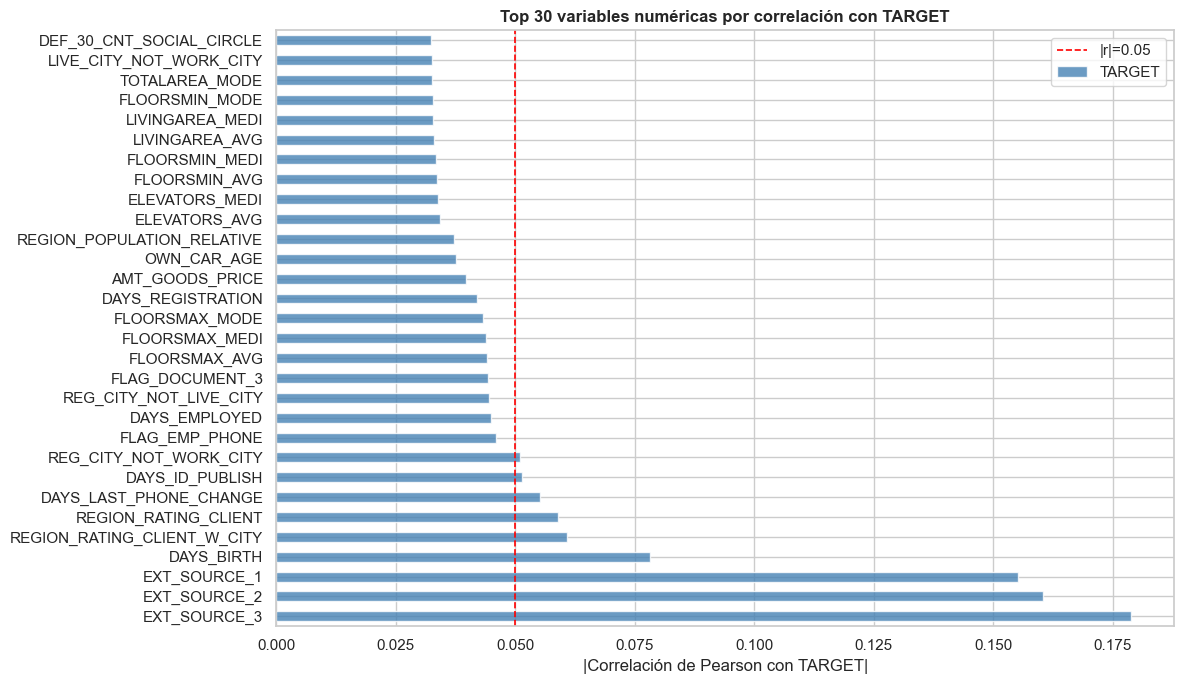

In [3]:
# Solo columnas numéricas
num_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != 'TARGET']

# Correlación de Pearson con TARGET (absoluta para ordenar)
corr_target = df_full[num_cols + ['TARGET']].corr()['TARGET'].drop('TARGET')
corr_abs    = corr_target.abs().sort_values(ascending=False)

print("Top 20 variables más correlacionadas con TARGET:")
print(corr_abs.head(20).round(4).to_string())

fig, ax = plt.subplots(figsize=(12, 7))
corr_abs.head(30).plot.barh(ax=ax, color='steelblue', alpha=0.8)
ax.axvline(0.05, color='red', ls='--', lw=1.2, label='|r|=0.05')
ax.set_xlabel('|Correlación de Pearson con TARGET|')
ax.set_title('Top 30 variables numéricas por correlación con TARGET',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_9676\3115135197.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_full.select_dtypes(include=['object']).columns.tolist()


Variables categóricas: 16
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


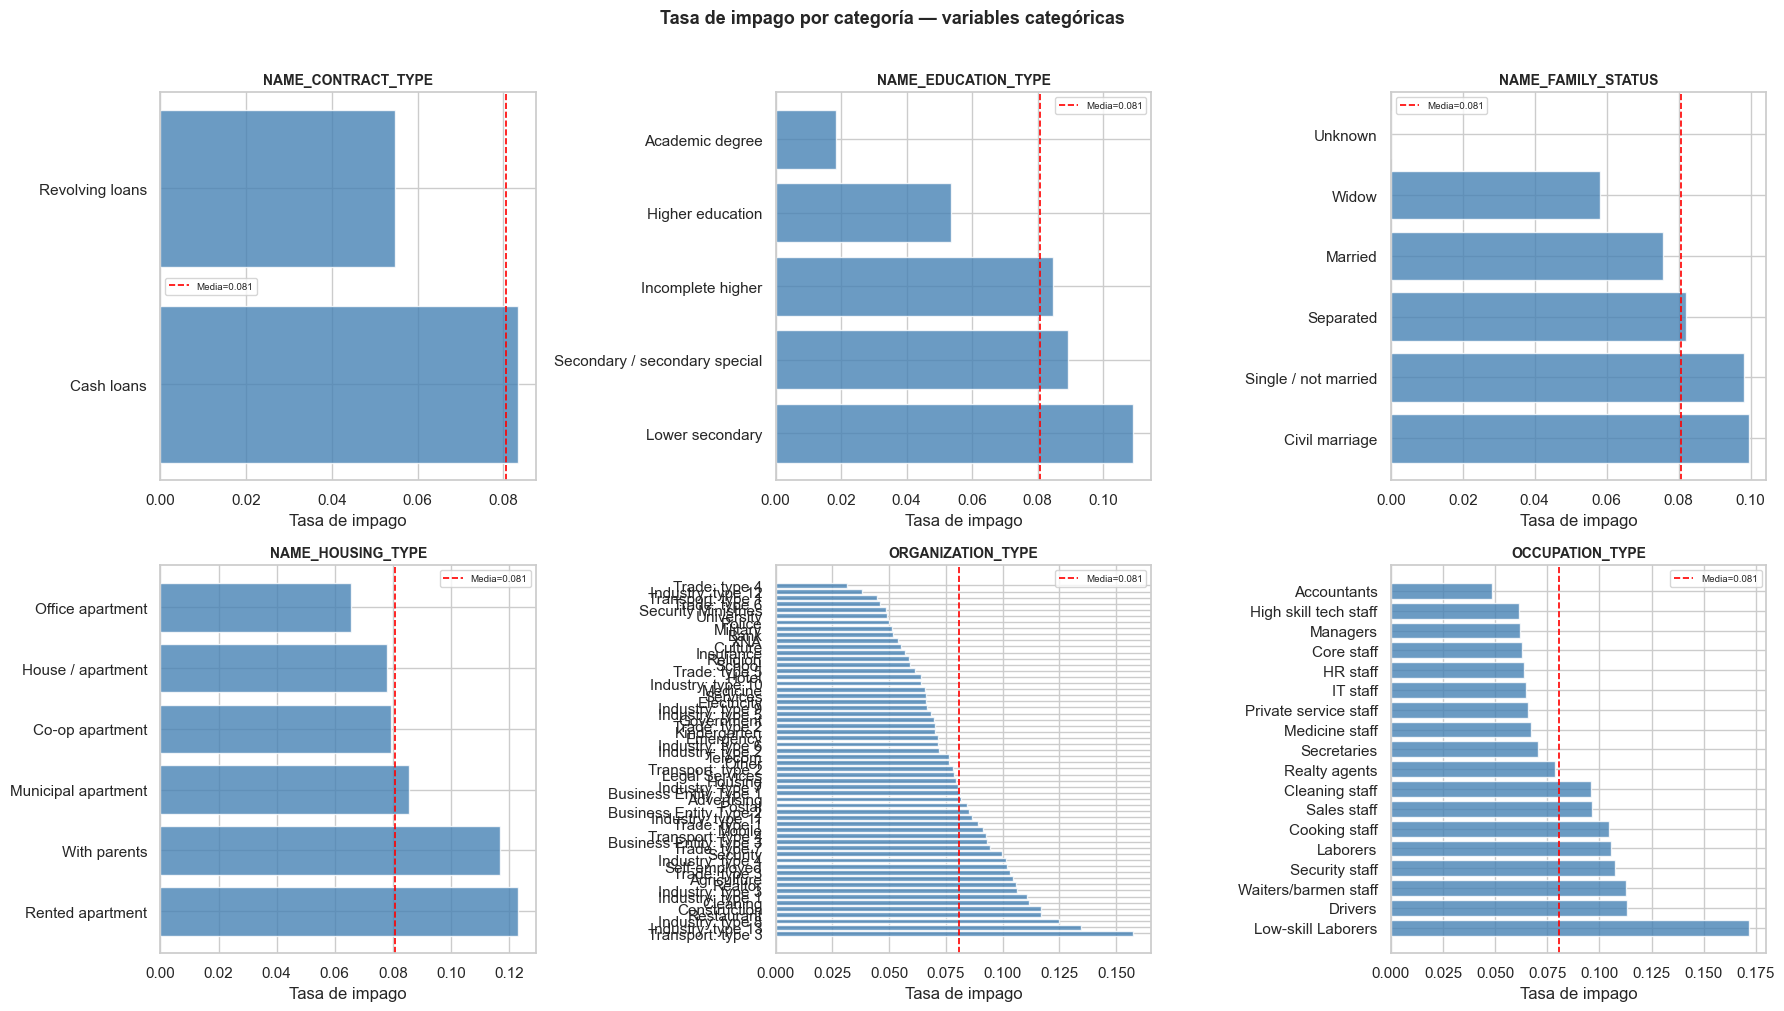

In [4]:
cat_cols = df_full.select_dtypes(include=['object']).columns.tolist()
print(f"Variables categóricas: {len(cat_cols)}")
print(cat_cols)

# Tasa de impago por categoría para las más interesantes
CATS_INTERES = [
    'NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
    'ORGANIZATION_TYPE', 'OCCUPATION_TYPE'
]
CATS_INTERES = [c for c in CATS_INTERES if c in df_full.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, CATS_INTERES):
    tasa = (df_full.groupby(col)['TARGET'].agg(['mean','count'])
            .sort_values('mean', ascending=False))
    bars = ax.barh(tasa.index.astype(str), tasa['mean'],
                   color='steelblue', alpha=0.8)
    ax.axvline(df_full['TARGET'].mean(), color='red', ls='--',
               lw=1.2, label=f'Media={df_full["TARGET"].mean():.3f}')
    ax.set_xlabel('Tasa de impago')
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
plt.suptitle('Tasa de impago por categoría — variables categóricas',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Top 20 — Spearman vs Pearson:
                             Spearman  Pearson
EXT_SOURCE_3                   0.1663   0.1789
EXT_SOURCE_1                   0.1511   0.1553
EXT_SOURCE_2                   0.1473   0.1605
DAYS_BIRTH                     0.0783   0.0782
REGION_RATING_CLIENT_W_CITY    0.0609   0.0609
REGION_RATING_CLIENT           0.0589   0.0589
DAYS_LAST_PHONE_CHANGE         0.0537   0.0552
OWN_CAR_AGE                    0.0529   0.0376
DAYS_ID_PUBLISH                0.0525   0.0515
REG_CITY_NOT_WORK_CITY         0.0510   0.0510
FLOORSMAX_AVG                  0.0462   0.0440
FLOORSMAX_MEDI                 0.0460   0.0438
FLAG_EMP_PHONE                 0.0460   0.0460
FLOORSMAX_MODE                 0.0454   0.0432
REG_CITY_NOT_LIVE_CITY         0.0444   0.0444
FLAG_DOCUMENT_3                0.0443   0.0443
LIVINGAREA_AVG                 0.0416   0.0330
LIVINGAREA_MEDI                0.0411   0.0327
DAYS_REGISTRATION              0.0402   0.0420
TOTALAREA_MODE                

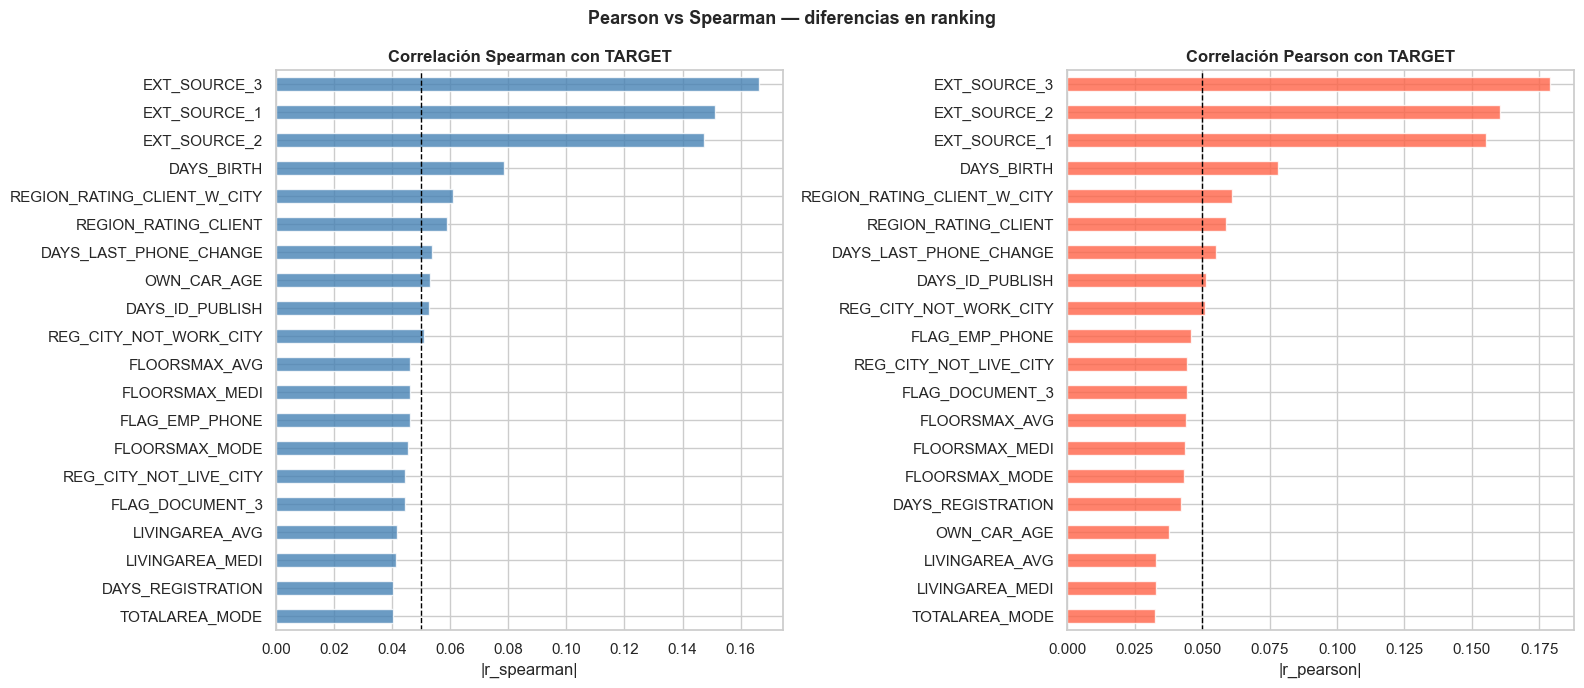


Variables que GANAN más con Spearman (relación no lineal):
YEARS_BEGINEXPLUATATION_MODE    0.0181
YEARS_BEGINEXPLUATATION_AVG     0.0177
YEARS_BEGINEXPLUATATION_MEDI    0.0176
OWN_CAR_AGE                     0.0153
AMT_INCOME_TOTAL                0.0141
LIVINGAREA_AVG                  0.0086
LIVINGAREA_MEDI                 0.0084
LIVINGAREA_MODE                 0.0084
TOTALAREA_MODE                  0.0075
AMT_REQ_CREDIT_BUREAU_QRT       0.0064

Variables que PIERDEN con Spearman:
CNT_FAM_MEMBERS              -0.0023
EXT_SOURCE_1                 -0.0042
AMT_REQ_CREDIT_BUREAU_MON    -0.0056
REGION_POPULATION_RELATIVE   -0.0067
AMT_GOODS_PRICE              -0.0082
EXT_SOURCE_3                 -0.0126
AMT_ANNUITY                  -0.0127
AMT_CREDIT                   -0.0128
EXT_SOURCE_2                 -0.0131
DAYS_EMPLOYED                -0.0198


In [5]:
# Spearman captura relaciones monótonas no lineales
# Mucho más adecuado para variables como DAYS_EMPLOYED que tienen outliers extremos

corr_spearman = (df_full[num_cols + ['TARGET']]
                 .corr(method='spearman')['TARGET']
                 .drop('TARGET'))
corr_spearman_abs = corr_spearman.abs().sort_values(ascending=False)

# Comparativa Pearson vs Spearman para el top 20
top20_s = corr_spearman_abs.head(20)
top20_p = corr_target.abs()[top20_s.index]

comparison = pd.DataFrame({
    'Spearman': top20_s,
    'Pearson':  top20_p
}).sort_values('Spearman', ascending=False)

print("Top 20 — Spearman vs Pearson:")
print(comparison.round(4).to_string())

# Plot comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col, color in zip(axes,
    ['Spearman', 'Pearson'], ['steelblue', 'tomato']):
    comparison[col].sort_values().plot.barh(ax=ax, color=color, alpha=0.8)
    ax.axvline(0.05, color='black', ls='--', lw=1)
    ax.set_title(f'Correlación {col} con TARGET', fontweight='bold')
    ax.set_xlabel(f'|r_{col.lower()}|')
plt.suptitle('Pearson vs Spearman — diferencias en ranking',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Variables que suben mucho con Spearman vs Pearson
diff = (corr_spearman_abs - corr_target.abs()).sort_values(ascending=False)
print("\nVariables que GANAN más con Spearman (relación no lineal):")
print(diff.head(10).round(4).to_string())
print("\nVariables que PIERDEN con Spearman:")
print(diff.tail(10).round(4).to_string())

Analizando 45 variables con 20-70% nulos...

Variables con muchos NaN ordenadas por discriminancia (Cohen's d):
                 variable  pct_nulos  media_T0  media_T1  cohen_d  n_validos
0            EXT_SOURCE_1    56.3811    0.5115    0.3870   0.5898     134133
1           FLOORSMAX_AVG    49.7608    0.2280    0.2030   0.1729     154491
2          FLOORSMAX_MEDI    49.7608    0.2276    0.2027   0.1719     154491
3          FLOORSMAX_MODE    49.7608    0.2240    0.1996   0.1698     154491
4             OWN_CAR_AGE    65.9908   11.9355   13.6687   0.1451     104582
5           ELEVATORS_AVG    53.2960    0.0802    0.0620   0.1349     143620
6          ELEVATORS_MEDI    53.2960    0.0793    0.0614   0.1336     143620
7           FLOORSMIN_AVG    67.8486    0.2334    0.2120   0.1327      98869
8          FLOORSMIN_MEDI    67.8486    0.2331    0.2118   0.1318      98869
9          LIVINGAREA_AVG    50.1933    0.1084    0.0941   0.1294     153161
10         FLOORSMIN_MODE    67.8486    0

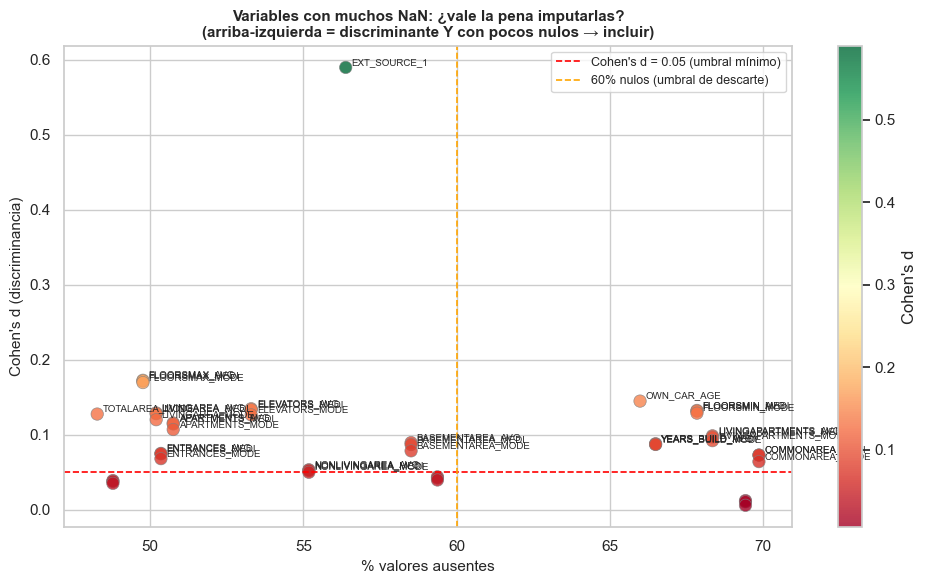

In [6]:
# Para cada variable con >20% nulos:
# comparamos la distribución de TARGET=0 vs TARGET=1 entre los NO nulos
# Si las distribuciones son distintas → la variable discrimina → vale la pena imputar
# Si son iguales → no aporta nada aunque la imputemos

HIGH_NA_COLS = na_pct[(na_pct > 20) & (na_pct <= 70)].index.tolist()
HIGH_NA_COLS = [c for c in HIGH_NA_COLS
                if df_full[c].dtype in [np.float64, np.int64]]

print(f"Analizando {len(HIGH_NA_COLS)} variables con 20-70% nulos...\n")

discriminancia = []
for col in HIGH_NA_COLS:
    sub = df_full[[col, 'TARGET']].dropna()
    if len(sub) < 1000:
        continue
    m0 = sub.loc[sub['TARGET'] == 0, col].mean()
    m1 = sub.loc[sub['TARGET'] == 1, col].mean()
    std_pool = sub[col].std()
    # Cohen's d: diferencia normalizada entre medias
    d = abs(m1 - m0) / (std_pool + 1e-9)
    discriminancia.append({
        'variable': col,
        'pct_nulos': na_pct[col],
        'media_T0': m0,
        'media_T1': m1,
        'cohen_d': d,
        'n_validos': len(sub)
    })

df_disc = (pd.DataFrame(discriminancia)
           .sort_values('cohen_d', ascending=False)
           .reset_index(drop=True))

print("Variables con muchos NaN ordenadas por discriminancia (Cohen's d):")
print(df_disc.head(20).round(4).to_string())

# Plot: discriminancia vs % nulos
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df_disc['pct_nulos'], df_disc['cohen_d'],
    c=df_disc['cohen_d'], cmap='RdYlGn',
    s=80, alpha=0.8, edgecolors='gray', linewidth=0.5
)
# Anotar las más discriminantes
for _, row in df_disc[df_disc['cohen_d'] > 0.05].iterrows():
    ax.annotate(row['variable'],
                (row['pct_nulos'], row['cohen_d']),
                fontsize=7, xytext=(4, 2),
                textcoords='offset points')
ax.axhline(0.05, color='red', ls='--', lw=1.2,
           label="Cohen's d = 0.05 (umbral mínimo)")
ax.axvline(60, color='orange', ls='--', lw=1.2,
           label='60% nulos (umbral de descarte)')
ax.set_xlabel('% valores ausentes', fontsize=11)
ax.set_ylabel("Cohen's d (discriminancia)", fontsize=11)
ax.set_title("Variables con muchos NaN: ¿vale la pena imputarlas?\n"
             "(arriba-izquierda = discriminante Y con pocos nulos → incluir)",
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.colorbar(scatter, label="Cohen's d")
plt.tight_layout()
plt.show()

In [7]:
# Cuántas categorías tiene cada una
cat_cols = df_full.select_dtypes(include='object').columns.tolist()
cat_info = pd.DataFrame({
    'n_categorias': [df_full[c].nunique() for c in cat_cols],
    'pct_nulos':    [df_full[c].isna().mean()*100 for c in cat_cols],
    'tasa_impago_std': [
        df_full.groupby(c)['TARGET'].mean().std()
        for c in cat_cols
    ]
}, index=cat_cols).sort_values('tasa_impago_std', ascending=False)

print("Variables categóricas — variabilidad en tasa de impago entre categorías:")
print(cat_info.round(4).to_string())

C:\Users\User\AppData\Local\Temp\ipykernel_9676\3686425680.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_full.select_dtypes(include='object').columns.tolist()


Variables categóricas — variabilidad en tasa de impago entre categorías:
                            n_categorias  pct_nulos  tasa_impago_std
NAME_INCOME_TYPE                       8     0.0000           0.1588
CODE_GENDER                            3     0.0000           0.0519
NAME_FAMILY_STATUS                     6     0.0000           0.0370
NAME_EDUCATION_TYPE                    5     0.0000           0.0356
OCCUPATION_TYPE                       18    31.3455           0.0300
ORGANIZATION_TYPE                     58     0.0000           0.0252
NAME_HOUSING_TYPE                      6     0.0000           0.0232
NAME_CONTRACT_TYPE                     2     0.0000           0.0203
EMERGENCYSTATE_MODE                    2    47.3983           0.0185
HOUSETYPE_MODE                         3    50.1761           0.0160
WALLSMATERIAL_MODE                     7    50.8408           0.0155
FLAG_OWN_CAR                           2     0.0000           0.0089
NAME_TYPE_SUITE               

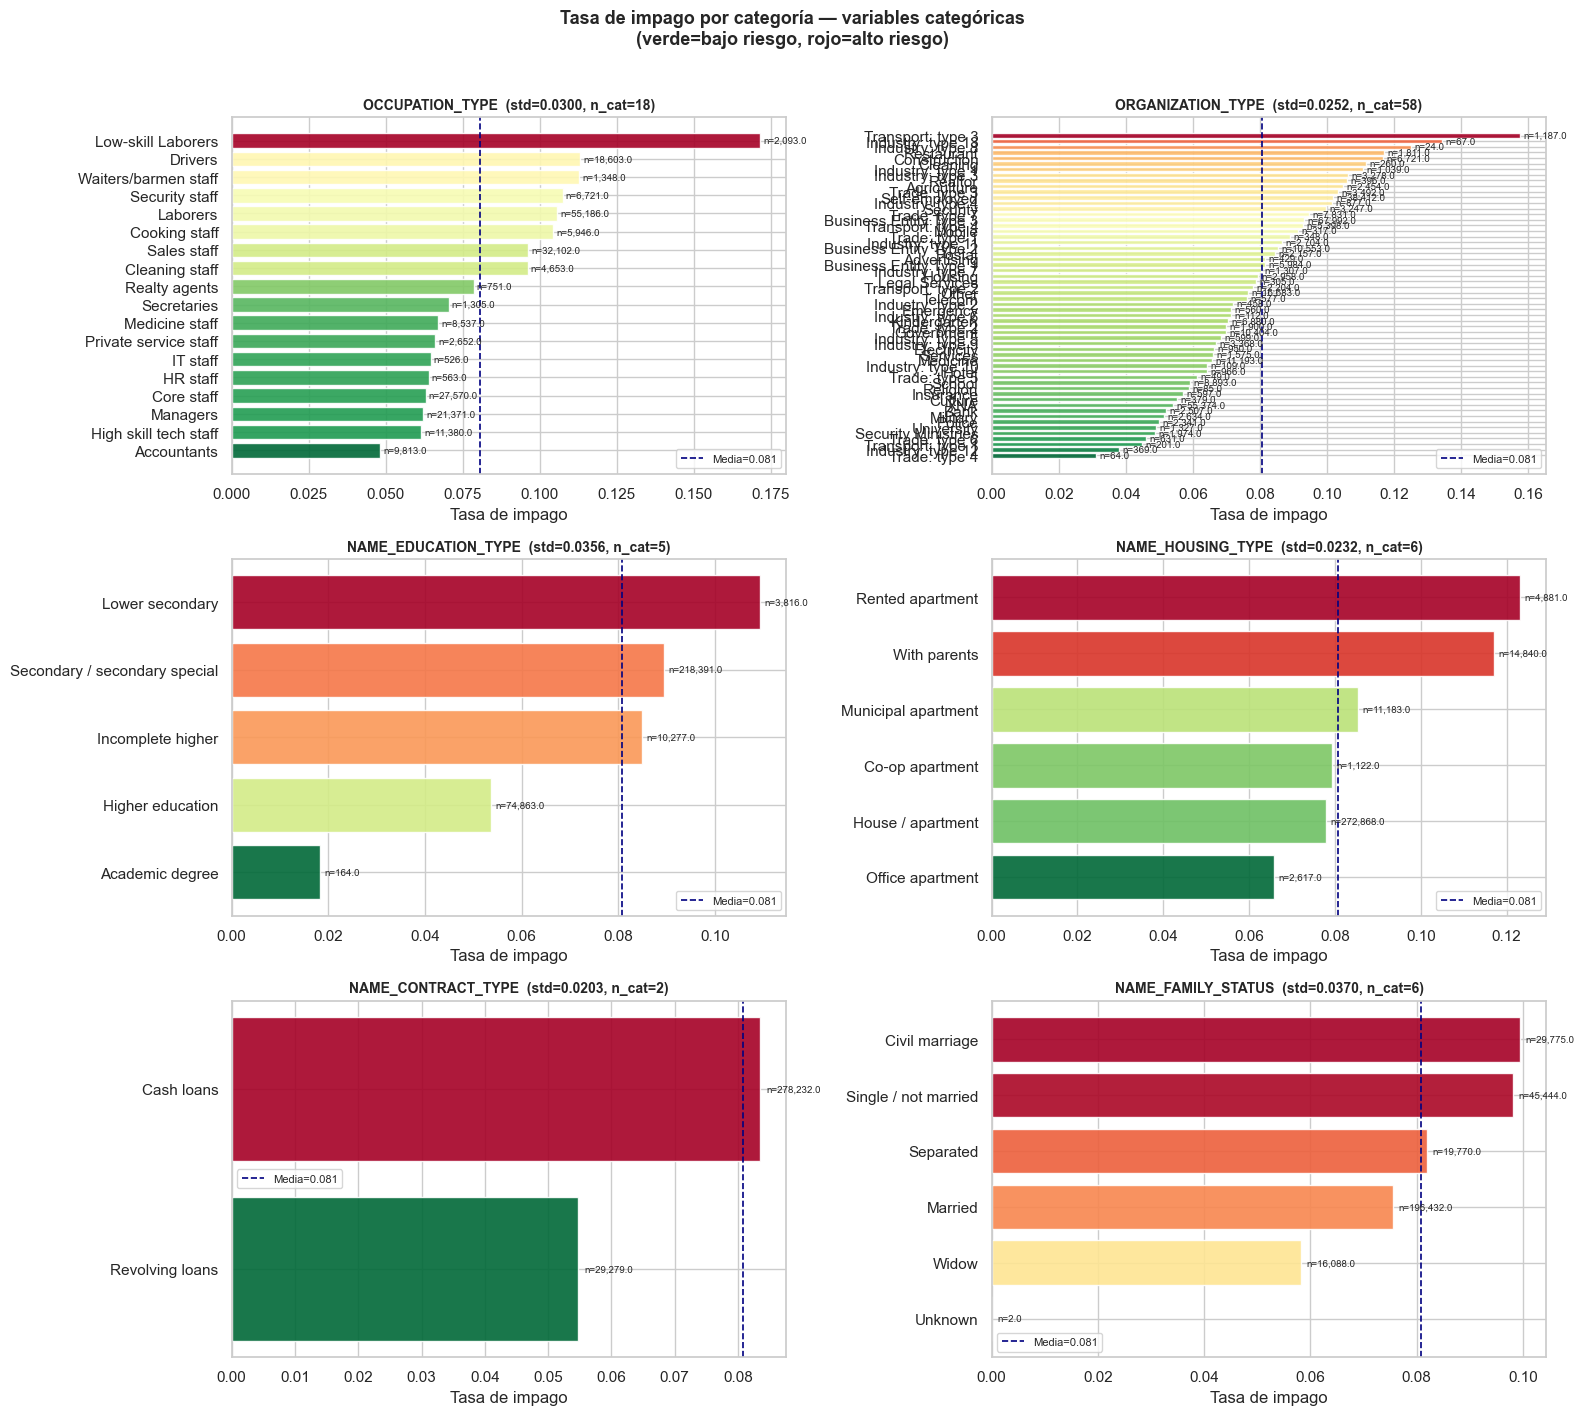

In [8]:
CATS_PLOT = ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE',
             'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE',
             'NAME_CONTRACT_TYPE', 'NAME_FAMILY_STATUS']
CATS_PLOT = [c for c in CATS_PLOT if c in df_full.columns]

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
for ax, col in zip(axes.flat, CATS_PLOT):
    tasa = (df_full.groupby(col)['TARGET']
            .agg(tasa='mean', n='count')
            .sort_values('tasa', ascending=True))

    colors = plt.cm.RdYlGn_r(
        (tasa['tasa'] - tasa['tasa'].min()) /
        (tasa['tasa'].max() - tasa['tasa'].min() + 1e-9)
    )
    bars = ax.barh(tasa.index.astype(str), tasa['tasa'],
                   color=colors, alpha=0.9)

    # Anotar n de cada categoría
    for bar, (_, row) in zip(bars, tasa.iterrows()):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'n={row["n"]:,}', va='center', fontsize=7)

    ax.axvline(df_full['TARGET'].mean(), color='navy',
               ls='--', lw=1.2, label=f'Media={df_full["TARGET"].mean():.3f}')
    ax.set_xlabel('Tasa de impago')
    ax.set_title(f'{col}  '
                 f'(std={tasa["tasa"].std():.4f}, '
                 f'n_cat={len(tasa)})',
                 fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Tasa de impago por categoría — variables categóricas\n'
             '(verde=bajo riesgo, rojo=alto riesgo)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Cardinalidad de las categóricas candidatas
for col in CATS_PLOT:
    if col in df_full.columns:
        n = df_full[col].nunique()
        na = df_full[col].isna().mean() * 100
        std = df_full.groupby(col)['TARGET'].mean().std()
        print(f"{col:<35} n_cat={n:>3}  nulos={na:>5.1f}%  std_tasa={std:.4f}")

OCCUPATION_TYPE                     n_cat= 18  nulos= 31.3%  std_tasa=0.0300
ORGANIZATION_TYPE                   n_cat= 58  nulos=  0.0%  std_tasa=0.0252
NAME_EDUCATION_TYPE                 n_cat=  5  nulos=  0.0%  std_tasa=0.0356
NAME_HOUSING_TYPE                   n_cat=  6  nulos=  0.0%  std_tasa=0.0232
NAME_CONTRACT_TYPE                  n_cat=  2  nulos=  0.0%  std_tasa=0.0203
NAME_FAMILY_STATUS                  n_cat=  6  nulos=  0.0%  std_tasa=0.0370


In [10]:
# DAYS_EMPLOYED = 365243 es un código especial para jubilados/sin empleo
# Si lo dejamos, dominaría el escalado y la red lo ignoraría

print("Distribución DAYS_EMPLOYED:")
print(df_full['DAYS_EMPLOYED'].value_counts().head(5))
print(f"\nValores = 365243: {(df_full['DAYS_EMPLOYED'] == 365243).sum()}")
print(f"Tasa impago con 365243: "
      f"{df_full.loc[df_full['DAYS_EMPLOYED']==365243,'TARGET'].mean():.4f}")
print(f"Tasa impago sin 365243: "
      f"{df_full.loc[df_full['DAYS_EMPLOYED']!=365243,'TARGET'].mean():.4f}")

# Decisión: crear flag + reemplazar por NaN + imputar mediana
df_full['DAYS_EMPLOYED_ANOMALY'] = (df_full['DAYS_EMPLOYED'] == 365243).astype(float)
df_full['DAYS_EMPLOYED'] = df_full['DAYS_EMPLOYED'].replace(365243, np.nan)
print(f"\nFlag DAYS_EMPLOYED_ANOMALY creado")
print(f"Tasa impago anomalía=1: "
      f"{df_full.loc[df_full['DAYS_EMPLOYED_ANOMALY']==1,'TARGET'].mean():.4f}")

Distribución DAYS_EMPLOYED:
DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
Name: count, dtype: int64

Valores = 365243: 55374
Tasa impago con 365243: 0.0540
Tasa impago sin 365243: 0.0866

Flag DAYS_EMPLOYED_ANOMALY creado
Tasa impago anomalía=1: 0.0540


C:\Users\User\AppData\Local\Temp\ipykernel_9676\4056876838.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_full['DAYS_EMPLOYED_ANOMALY'] = (df_full['DAYS_EMPLOYED'] == 365243).astype(float)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

# ── Definición de features ────────────────────────────────────────────────
ORIGINAL_COLS = [
    'CODE_GENDER', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]
# Nuevas numéricas
NEW_NUM_COLS = [
    'REGION_RATING_CLIENT_W_CITY', 'DAYS_LAST_PHONE_CHANGE',
    'OWN_CAR_AGE', 'DAYS_ID_PUBLISH', 'REG_CITY_NOT_WORK_CITY',
    'FLAG_EMP_PHONE', 'DAYS_REGISTRATION', 'AMT_GOODS_PRICE', 'DAYS_EMPLOYED'
]
# Categóricas
CAT_ONEHOT = ['NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE',
              'NAME_HOUSING_TYPE']
CAT_BINARY = ['NAME_CONTRACT_TYPE']
CAT_TARGET = ['NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
# Días (negativos → positivos)
DAYS_COLS  = ['DAYS_BIRTH', 'DAYS_LAST_PHONE_CHANGE',
              'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION', 'DAYS_EMPLOYED']
# log1p
LOG_COLS   = ['AMT_INCOME_TOTAL', 'AMT_CREDIT',
              'AMT_ANNUITY', 'AMT_GOODS_PRICE']
# Máscaras de ausencia
MASK_COLS  = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OWN_CAR_AGE',
              'DAYS_EMPLOYED', 'OCCUPATION_TYPE']

# ── 1. Limpieza base ──────────────────────────────────────────────────────
df = df_full.copy()
df = df[df['CODE_GENDER'] != 'XNA'].copy()
df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1})
df['AGE_YEARS']   = np.abs(df['DAYS_BIRTH']) / 365
df['NAME_CONTRACT_TYPE'] = (df['NAME_CONTRACT_TYPE'] == 'Cash loans').astype(float)

# ── 2. Días → positivos ───────────────────────────────────────────────────
for c in DAYS_COLS:
    if c in df.columns:
        df[c] = np.abs(df[c])

# ── 3. Feature engineering original ──────────────────────────────────────
df['DEBT_RATIO'] = (
    df['AMT_ANNUITY'].fillna(df['AMT_ANNUITY'].median()) /
    df['AMT_INCOME_TOTAL']
).clip(upper=3.0)

# ── 4. Máscaras de ausencia ───────────────────────────────────────────────
for c in MASK_COLS:
    if c in df.columns:
        df[f'{c}_MISSING'] = df[c].isna().astype(float)

# ── 5. Split ANTES de cualquier encoding ──────────────────────────────────
# CRÍTICO: target encoding y scalers se ajustan SOLO en train
TARGET_COL   = 'TARGET'
SENSITIVE_COL = 'CODE_GENDER'

all_feature_cols = (
    ORIGINAL_COLS + ['AGE_YEARS', 'DEBT_RATIO'] +
    NEW_NUM_COLS + ['DAYS_EMPLOYED_ANOMALY'] +
    CAT_BINARY + CAT_ONEHOT + CAT_TARGET +
    [f'{c}_MISSING' for c in MASK_COLS if c in df.columns]
)
# Filtrar columnas que existen
all_feature_cols = [c for c in all_feature_cols if c in df.columns]

X = df[all_feature_cols].copy()
y = df[TARGET_COL]
s = df[SENSITIVE_COL]

X_tr, X_tmp, y_tr, y_tmp, s_tr, s_tmp = train_test_split(
    X, y, s, test_size=0.40, stratify=y, random_state=42)
X_val, X_te, y_val, y_te, s_val, s_te = train_test_split(
    X_tmp, y_tmp, s_tmp, test_size=0.50, stratify=y_tmp, random_state=42)

print(f"Train: {X_tr.shape}  Val: {X_val.shape}  Test: {X_te.shape}")

# ── 6. Target encoding (ajustado SOLO en train) ───────────────────────────
def target_encode(X_tr, X_val, X_te, col, y_tr, smoothing=20):
    """
    Target encoding con smoothing para evitar overfitting en categorías raras.
    smooth = (n_cat * mean_cat + smoothing * global_mean) / (n_cat + smoothing)
    """
    global_mean = y_tr.mean()
    stats = (pd.DataFrame({'cat': X_tr[col], 'y': y_tr})
               .groupby('cat')['y']
               .agg(['mean', 'count']))
    stats['smooth'] = (
        (stats['count'] * stats['mean'] + smoothing * global_mean) /
        (stats['count'] + smoothing)
    )
    encode_map = stats['smooth'].to_dict()
    for split in (X_tr, X_val, X_te):
        split[col] = split[col].map(encode_map).fillna(global_mean)
    return X_tr, X_val, X_te

for col in CAT_TARGET:
    if col in X_tr.columns:
        X_tr, X_val, X_te = target_encode(X_tr, X_val, X_te, col, y_tr)
        print(f"  Target encoding: {col}")

# ── 7. One-hot encoding (ajustado en train) ───────────────────────────────
for col in CAT_ONEHOT:
    if col not in X_tr.columns:
        continue
    cats = X_tr[col].dropna().unique().tolist()
    for cat in cats[:-1]:   # drop_first para evitar multicolinealidad
        safe = cat.replace(' ', '_').replace('/', '_')
        col_name = f'{col}_{safe}'
        for split in (X_tr, X_val, X_te):
            split[col_name] = (split[col] == cat).astype(float)
    for split in (X_tr, X_val, X_te):
        split.drop(columns=[col], inplace=True)
    print(f"  One-hot: {col} → {len(cats)-1} columnas")

# ── 8. Imputación mediana (ajustada SOLO en train) ────────────────────────
# Nota: CAT_TARGET ya fue rellenado con global_mean en target_encode()
# Solo imputamos columnas que aún pueden tener NaN
IMPUTE_COLS = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'OWN_CAR_AGE', 'DAYS_EMPLOYED'
]
# Filtrar solo las que existen y tienen NaN en train
IMPUTE_COLS = [c for c in IMPUTE_COLS
               if c in X_tr.columns and X_tr[c].isna().sum() > 0]

print(f"Columnas a imputar: {IMPUTE_COLS}")

medians_train = X_tr[IMPUTE_COLS].median()
for split in (X_tr, X_val, X_te):
    for col in IMPUTE_COLS:          # columna a columna evita el bug de duplicados
        split[col] = split[col].fillna(medians_train[col])

# Verificar que no quedan NaN
nulos_restantes = X_tr[IMPUTE_COLS].isna().sum()
print(f"Nulos tras imputación:\n{nulos_restantes[nulos_restantes > 0]}")
print("✅ Sin nulos residuales" if nulos_restantes.sum() == 0
      else "⚠️ Aún hay nulos")

# ── 9. log1p en monetarias ────────────────────────────────────────────────
LOG_COLS_ACT = [c for c in LOG_COLS if c in X_tr.columns]
for split in (X_tr, X_val, X_te):
    split[LOG_COLS_ACT] = np.log1p(split[LOG_COLS_ACT])

# ── 10. StandardScaler (ajustado SOLO en train) ───────────────────────────
# No escalar: binarias, flags, máscaras, DEBT_RATIO, one-hot
BINARY_LIKE = (['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'REG_CITY_NOT_WORK_CITY',
                'FLAG_EMP_PHONE', 'DEBT_RATIO', 'DAYS_EMPLOYED_ANOMALY'] +
               [f'{c}_MISSING' for c in MASK_COLS] +
               [c for c in X_tr.columns
                if any(c.startswith(f'{oh}_') for oh in CAT_ONEHOT)])

SCALE_COLS = [c for c in X_tr.columns if c not in BINARY_LIKE]
scaler_ext = StandardScaler()
scaler_ext.fit(X_tr[SCALE_COLS])
for split in (X_tr, X_val, X_te):
    split[SCALE_COLS] = scaler_ext.transform(split[SCALE_COLS])

# ── Verificación final ────────────────────────────────────────────────────
FEATURE_COLS_EXT = list(X_tr.columns)
N_FEATURES_EXT   = len(FEATURE_COLS_EXT)

print(f"\n✅ Pipeline completado")
print(f"   Features totales:  {N_FEATURES_EXT}")
print(f"   Train shape:       {X_tr.shape}")
print(f"   Nulos en train:    {X_tr.isna().sum().sum()}")

# Convertir a numpy
X_tr_np  = X_tr.values.astype(np.float32)
X_val_np = X_val.values.astype(np.float32)
X_te_np  = X_te.values.astype(np.float32)
y_tr_np  = y_tr.values.astype(np.float32)
y_val_np = y_val.values.astype(np.float32)
y_te_np  = y_te.values.astype(np.float32)

print(f"\nFeatures finales ({N_FEATURES_EXT}):")
for i, c in enumerate(FEATURE_COLS_EXT):
    print(f"  {i:>3}. {c}")

Train: (184504, 32)  Val: (61501, 32)  Test: (61502, 32)
  Target encoding: NAME_INCOME_TYPE
  Target encoding: OCCUPATION_TYPE
  Target encoding: ORGANIZATION_TYPE
  One-hot: NAME_FAMILY_STATUS → 4 columnas
  One-hot: NAME_EDUCATION_TYPE → 4 columnas
  One-hot: NAME_HOUSING_TYPE → 5 columnas
Columnas a imputar: ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'OWN_CAR_AGE', 'DAYS_EMPLOYED']
Nulos tras imputación:
Series([], dtype: int64)
✅ Sin nulos residuales

✅ Pipeline completado
   Features totales:  42
   Train shape:       (184504, 42)
   Nulos en train:    1

Features finales (42):
    0. CODE_GENDER
    1. AMT_INCOME_TOTAL
    2. AMT_CREDIT
    3. AMT_ANNUITY
    4. EXT_SOURCE_1
    5. EXT_SOURCE_2
    6. EXT_SOURCE_3
    7. AGE_YEARS
    8. DEBT_RATIO
    9. REGION_RATING_CLIENT_W_CITY
   10. DAYS_LAST_PHONE_CHANGE
   11. OWN_CAR_AGE
   12. DAYS_ID_PUBLISH
   13. REG_CITY_NOT_WORK_CITY
   14. FLAG_EMP_PHONE
   15. DAYS_REGISTRATION
   16. AMT

In [13]:
# ELIMINAMOS EN NULO RESIDUAL
# 1 nulo en train — localizarlo
nulos_por_col = X_tr.isna().sum()
col_con_nulo  = nulos_por_col[nulos_por_col > 0]
print(f"Columna con nulo residual: {col_con_nulo}")
print(f"Fila con nulo:")
print(X_tr[X_tr.isna().any(axis=1)])

# Imputar con 0 (es casi seguro una columna binaria o flag)
for split in (X_tr_np, X_val_np, X_te_np):
    pass  # ya convertidos a numpy, np.nan en float32 → rellenar aquí

# Rehacer la conversión limpiando NaN residuales
X_tr_np  = np.nan_to_num(X_tr.values.astype(np.float32), nan=0.0)
X_val_np = np.nan_to_num(X_val.values.astype(np.float32), nan=0.0)
X_te_np  = np.nan_to_num(X_te.values.astype(np.float32), nan=0.0)

print(f"\nNulos en arrays numpy:")
print(f"  Train: {np.isnan(X_tr_np).sum()}")
print(f"  Val:   {np.isnan(X_val_np).sum()}")
print(f"  Test:  {np.isnan(X_te_np).sum()}")
print("✅ Arrays limpios")

Columna con nulo residual: DAYS_LAST_PHONE_CHANGE    1
dtype: int64
Fila con nulo:
       CODE_GENDER  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  EXT_SOURCE_1  \
15709            0         -0.338461   -0.742034     0.174017      0.014606   

       EXT_SOURCE_2  EXT_SOURCE_3  AGE_YEARS  DEBT_RATIO  \
15709       0.27148       0.11332   -1.71114    0.205643   

       REGION_RATING_CLIENT_W_CITY  ...  NAME_FAMILY_STATUS_Civil_marriage  \
15709                    -0.062173  ...                                0.0   

       NAME_EDUCATION_TYPE_Secondary___secondary_special  \
15709                                                0.0   

       NAME_EDUCATION_TYPE_Higher_education  \
15709                                   0.0   

       NAME_EDUCATION_TYPE_Incomplete_higher  \
15709                                    1.0   

       NAME_EDUCATION_TYPE_Lower_secondary  \
15709                                  0.0   

       NAME_HOUSING_TYPE_House___apartment  NAME_HOUSING_TYPE_Co-op_apartm

In [15]:
pip install keras

  Using cached keras-3.14.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached h5py-3.16.0-cp311-cp311-win_amd64.whl.metadata (3.1 kB)
  Using cached optree-0.19.1-cp311-cp311-win_amd64.whl.metadata (32 kB)
  Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
Using cached keras-3.14.1-py3-none-any.whl (1.6 MB)
Using cached absl_py-2.4.0-py3-none-any.whl (135 kB)
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------- ----------------------- 1.3/3.2 MB 6.7 MB/s eta 0:00:01
   ------------------------------------ --- 2.9/3.2 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 6.9 MB/s  0:00:00
Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl (210 kB)
Using cached namex-0.1.0-py3-none-any.whl (5.9 kB)
Using cached optree-0.19.1-cp311-cp311-win_amd64.whl (337 kB)

   ----------

In [17]:
pip install tensorflow

  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl.metadata (2.7 kB)
Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl (350.8 MB)
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ---------- ----------------------------- 1.3/4.9 MB 7.4 MB/s eta 0:00:01
   ----------------------- ---------------- 2.9/4.9 MB 7.6 MB/s eta 0:00:01
   -------------------------------------- - 4.7/4.9 MB 8.1 MB/s eta 0:00:01

In [18]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics             import roc_auc_score
import keras
from keras import layers, Input, Model
from keras.metrics   import AUC
from keras.callbacks import EarlyStopping

keras.utils.set_random_seed(42)

# Índices de las capas custom en el nuevo tensor de 42 features
DEBT_RATIO_IDX_EXT = FEATURE_COLS_EXT.index('DEBT_RATIO')
EXT_IDXS_EXT       = [FEATURE_COLS_EXT.index(c) for c in
                       ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]

print(f"DEBT_RATIO    → columna {DEBT_RATIO_IDX_EXT}")
print(f"EXT_SOURCE_*  → columnas {EXT_IDXS_EXT}")
print(f"Total features: {N_FEATURES_EXT}")

# Class weights
weights = compute_class_weight('balanced',
                                classes=np.array([0, 1]),
                                y=y_tr_np)
CLASS_WEIGHT_EXT = {0: float(weights[0]), 1: float(weights[1])}
print(f"\nClass weights: {CLASS_WEIGHT_EXT}")

# Callbacks comunes
def get_callbacks(patience=25):
    return [
        EarlyStopping(
            monitor='val_auc', mode='max',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_auc', mode='max',
            factor=0.3, patience=8,
            min_lr=1e-7, verbose=1
        )
    ]

DEBT_RATIO    → columna 8
EXT_SOURCE_*  → columnas [4, 5, 6]
Total features: 42

Class weights: {0: 0.5439098161064566, 1: 6.193487747566297}


In [20]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

def plot_curves_ext(history, model_name: str, zoom_n: int = 30,
                    save: bool = False):
    """
    Curvas de pérdida y AUC con zoom + evolución del LR.
    Versión para el notebook de features extendidas.
    """
    n  = len(history.history['loss'])
    zs = max(0, n - zoom_n)
    ep = list(range(1, n + 1))

    best_auc   = max(history.history['val_auc'])
    best_epoch = history.history['val_auc'].index(best_auc) + 1
    lrs        = history.history.get('learning_rate', [None] * n)
    has_lr     = lrs[0] is not None

    nrows = 3 if has_lr else 2
    fig   = plt.figure(figsize=(16, 5 * nrows))
    gs    = fig.add_gridspec(nrows, 2, hspace=0.45, wspace=0.3)
    fig.suptitle(
        f'{model_name}\n'
        f'Mejor AUC val = {best_auc:.4f}  (época {best_epoch}/{n})  '
        f'| Features: {N_FEATURES_EXT}',
        fontsize=13, fontweight='bold'
    )

    for row, (metric, ylabel) in enumerate([('loss', 'BCE Loss'),
                                             ('auc',  'AUC-ROC')]):
        tr = history.history[metric]
        vl = history.history[f'val_{metric}']

        # Curva completa
        ax = fig.add_subplot(gs[row, 0])
        ax.plot(ep, tr, color='steelblue', lw=1.5, label='Train')
        ax.plot(ep, vl, color='tomato',    lw=1.5, label='Val')
        ax.axvline(best_epoch, color='green', ls='--', lw=1.2,
                   label=f'Mejor val (é.{best_epoch})')
        ax.set(title=f'{ylabel} — Curva completa',
               xlabel='Época', ylabel=ylabel)
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

        # Zoom últimas épocas
        ax = fig.add_subplot(gs[row, 1])
        ax.plot(ep[zs:], tr[zs:], color='steelblue', lw=1.5,
                marker='o', ms=3, label='Train')
        ax.plot(ep[zs:], vl[zs:], color='tomato', lw=1.5,
                marker='o', ms=3, label='Val')
        if best_epoch > zs:
            ax.axvline(best_epoch, color='green', ls='--', lw=1.2,
                       label=f'Mejor val (é.{best_epoch})')
        ax.set(title=f'{ylabel} — Zoom últimas {zoom_n} épocas',
               xlabel='Época', ylabel=ylabel)
        ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # LR
    if has_lr:
        ax_lr = fig.add_subplot(gs[2, :])
        ax_lr.semilogy(ep, lrs, color='purple', lw=1.5)
        ax_lr.axvline(best_epoch, color='green', ls='--', lw=1.2,
                      label=f'Mejor val (é.{best_epoch})')
        n_reducciones = sum(
            1 for i in range(1, len(lrs)) if lrs[i] < lrs[i-1]
        )
        ax_lr.set(title=f'Evolución del Learning Rate (escala log) '
                        f'— {n_reducciones} reducciones',
                  xlabel='Época', ylabel='LR')
        ax_lr.legend(fontsize=9); ax_lr.grid(alpha=0.3, which='both')

    plt.tight_layout()

    if save:
        import os
        os.makedirs('report_plots', exist_ok=True)
        safe = model_name.replace(' ', '_').replace('*','star')
        path = f'report_plots/curves_ext_{safe}.pdf'
        plt.savefig(path, dpi=150, bbox_inches='tight')
        print(f"  💾 {path}")

    plt.show()
    return fig, best_auc, best_epoch


def plot_comparison_bar(resultados: list, save: bool = False):
    """
    Barras horizontales comparando AUC test: 12 features vs 42 features.

    resultados: lista de dicts con keys:
      nombre, n_features, auc_test, es_extendido (bool)
    """
    fig, ax = plt.subplots(figsize=(13, 6))

    colores = []
    for r in resultados:
        if 'M0' in r['nombre']:
            colores.append('#AED6F1' if not r['es_extendido'] else '#2980B9')
        elif 'M3' in r['nombre']:
            colores.append('#A9DFBF' if not r['es_extendido'] else '#27AE60')
        else:
            colores.append('#F9E79F' if not r['es_extendido'] else '#F39C12')

    nombres   = [r['nombre']   for r in resultados]
    aucs_test = [r['auc_test'] for r in resultados]

    bars = ax.barh(nombres, aucs_test, color=colores,
                   alpha=0.9, edgecolor='gray', linewidth=0.8)
    ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10, fontweight='bold')

    # Líneas de referencia
    ax.axvline(0.7457, color='green', ls='--', lw=1.2, alpha=0.6,
               label='M3 original mejor (0.7457)')
    ax.axvline(0.7335, color='gray',  ls=':', lw=1.2, alpha=0.6,
               label='M0 baseline (0.7335)')

    ax.set_xlabel('AUC-ROC (test)', fontsize=11)
    ax.set_title('12 features originales vs 42 features extendidas\n'
                 '(colores oscuros = extendido)',
                 fontsize=12, fontweight='bold')

    # Leyenda de colores por modelo
    import matplotlib.patches as mpatches
    legend_elements = [
        mpatches.Patch(facecolor='#AED6F1', label='M0 original'),
        mpatches.Patch(facecolor='#2980B9', label='M0 extendido'),
        mpatches.Patch(facecolor='#A9DFBF', label='M3 original'),
        mpatches.Patch(facecolor='#27AE60', label='M3 extendido'),
        mpatches.Patch(facecolor='#F9E79F', label='M6 original'),
        mpatches.Patch(facecolor='#F39C12', label='M6 extendido'),
    ]
    ax.legend(handles=legend_elements + [
        plt.Line2D([0],[0], color='green', ls='--', label='M3 original mejor'),
        plt.Line2D([0],[0], color='gray',  ls=':',  label='M0 baseline'),
    ], fontsize=9, loc='lower right')

    xmin = min(aucs_test) - 0.005
    xmax = max(aucs_test) + 0.008
    ax.set_xlim(xmin, xmax)
    ax.grid(alpha=0.3, axis='x')
    plt.tight_layout()

    if save:
        import os
        os.makedirs('report_plots', exist_ok=True)
        plt.savefig('report_plots/12_extended_features_comparison.pdf',
                    dpi=150, bbox_inches='tight')
        print("  💾 report_plots/12_extended_features_comparison.pdf")

    plt.show()
    return fig

print("✅ Funciones de visualización cargadas:")
print("   · plot_curves_ext(history, nombre, zoom_n=30, save=False)")
print("   · plot_comparison_bar(resultados, save=False)")

✅ Funciones de visualización cargadas:
   · plot_curves_ext(history, nombre, zoom_n=30, save=False)
   · plot_comparison_bar(resultados, save=False)


In [19]:
# M0: regresión logística con 42 features
# Pregunta: ¿cuánto sube el AUC lineal con más variables?

keras.utils.set_random_seed(42)
inputs_ext = Input(shape=(N_FEATURES_EXT,), name='input')
output_m0  = layers.Dense(1, activation='sigmoid', name='output')(inputs_ext)
model_m0_ext = Model(inputs_ext, output_m0, name='M0_ext')

model_m0_ext.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[AUC(name='auc')]
)
model_m0_ext.summary()

history_m0_ext = model_m0_ext.fit(
    X_tr_np, y_tr_np,
    validation_data=(X_val_np, y_val_np),
    epochs=200, batch_size=512,
    class_weight=CLASS_WEIGHT_EXT,
    callbacks=get_callbacks(patience=20),
    verbose=0
)

auc_m0_ext_val  = max(history_m0_ext.history['val_auc'])
auc_m0_ext_test = roc_auc_score(
    y_te_np, model_m0_ext.predict(X_te_np, verbose=0).ravel())

print(f"\nM0 (12 features): 0.7335  →  M0 extendido (42 features): {auc_m0_ext_test:.4f}")
print(f"Ganancia: {auc_m0_ext_test - 0.7335:+.4f}")

Model: "M0_ext"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            43 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43 (172.00 B)

 Trainable params: 43 (172.00 B)

 Non-trainable params: 0 (0.00 B)


Epoch 62: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 80: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 88: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.

Epoch 96: ReduceLROnPlateau reducing learning rate to 8.100000013655517e-06.
Epoch 100: early stopping
Restoring model weights from the end of the best epoch: 80.

M0 (12 features): 0.7335  →  M0 extendido (42 features): 0.7501
Ganancia: +0.0166


C:\Users\User\AppData\Local\Temp\ipykernel_9676\406388133.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  💾 report_plots/curves_ext_M0_extendido_—_Reg._Logística_(42_features).pdf


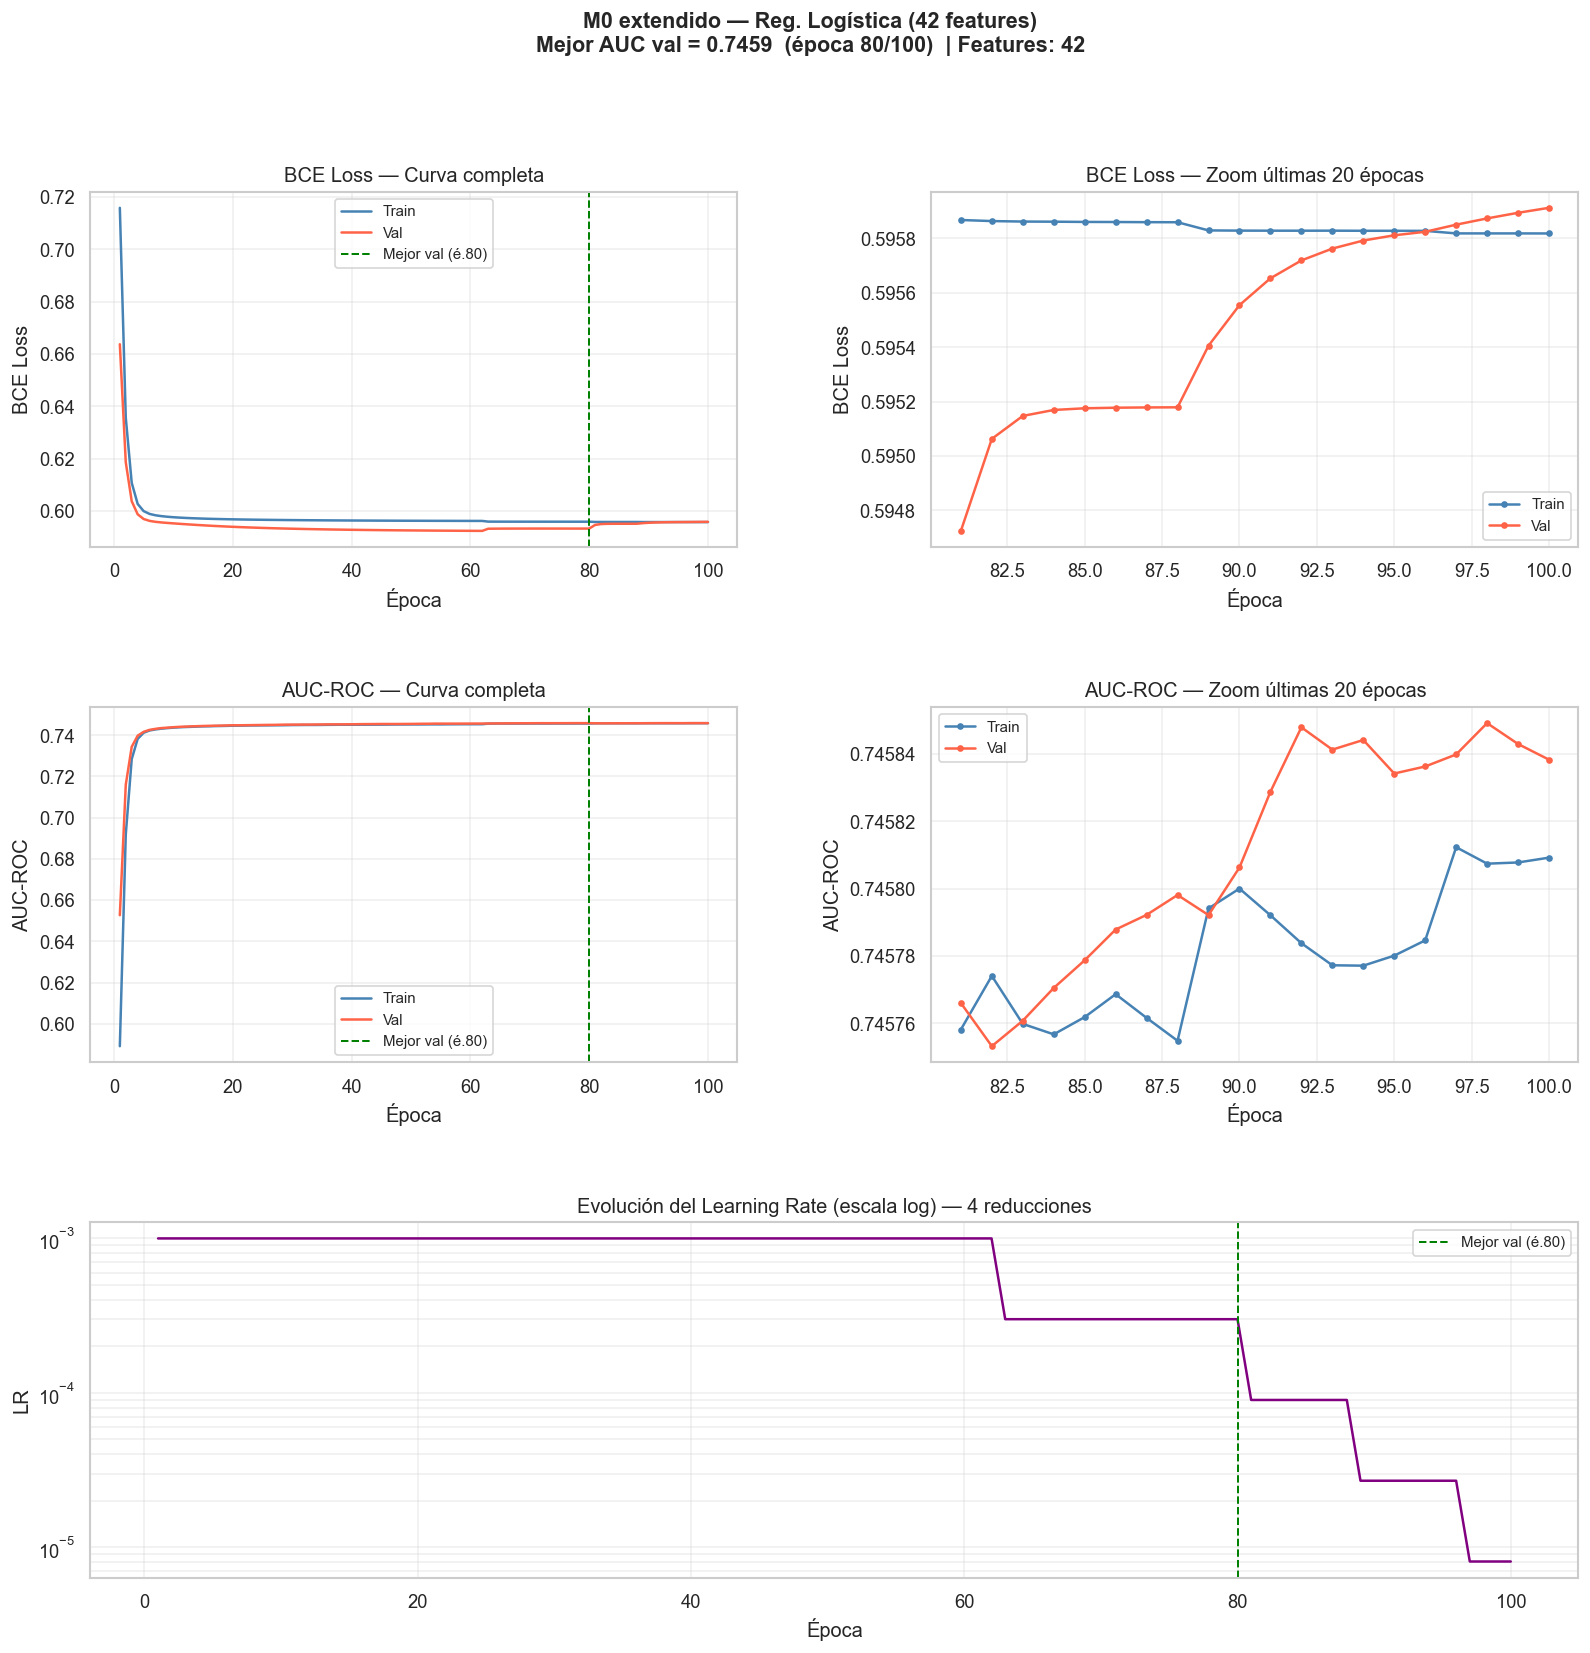

(<Figure size 1920x1800 with 5 Axes>, 0.7458529472351074, 80)

In [21]:
plot_curves_ext(history_m0_ext, 'M0 extendido — Reg. Logística (42 features)',
                zoom_n=20, save=True)

In [22]:
keras.utils.set_random_seed(42)

inputs_ext = Input(shape=(N_FEATURES_EXT,), name='input')
x = layers.Dense(256, activation='relu', name='dense_1')(inputs_ext)
x = layers.Dropout(0.30,                 name='dropout_1')(x)
x = layers.Dense(128, activation='relu', name='dense_2')(x)
x = layers.Dropout(0.20,                 name='dropout_2')(x)
x = layers.Dense(64,  activation='relu', name='dense_3')(x)
x = layers.Dropout(0.10,                 name='dropout_3')(x)
output_m3 = layers.Dense(1, activation='sigmoid', name='output')(x)
model_m3_ext = Model(inputs_ext, output_m3, name='M3_ext')

# Justificación de la arquitectura ampliada:
# Con 42 features en vez de 12, la primera capa puede ser más ancha (256)
# para capturar más interacciones. Añadimos una tercera capa oculta (64)
# con poco dropout (0.10) para refinar sin regularizar demasiado.

model_m3_ext.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[AUC(name='auc')]
)
model_m3_ext.summary()

history_m3_ext = model_m3_ext.fit(
    X_tr_np, y_tr_np,
    validation_data=(X_val_np, y_val_np),
    epochs=300, batch_size=512,
    class_weight=CLASS_WEIGHT_EXT,
    callbacks=get_callbacks(patience=30),
    verbose=0
)

auc_m3_ext_val  = max(history_m3_ext.history['val_auc'])
auc_m3_ext_test = roc_auc_score(
    y_te_np, model_m3_ext.predict(X_te_np, verbose=0).ravel())

print(f"\nM3 (12 features): 0.7457  →  M3 extendido (42 features): {auc_m3_ext_test:.4f}")
print(f"Ganancia: {auc_m3_ext_test - 0.7457:+.4f}")

Model: "M3_ext"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        11,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,225 (204.00 KB)

 Trainable params: 52,225 (204.00 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 28: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 36: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 12.

M3 (12 features): 0.7457  →  M3 extendido (42 features): 0.7555
Ganancia: +0.0098


C:\Users\User\AppData\Local\Temp\ipykernel_9676\406388133.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  💾 report_plots/curves_ext_M3_extendido_—_MLP_3_capas_+_Dropout_(42_features).pdf


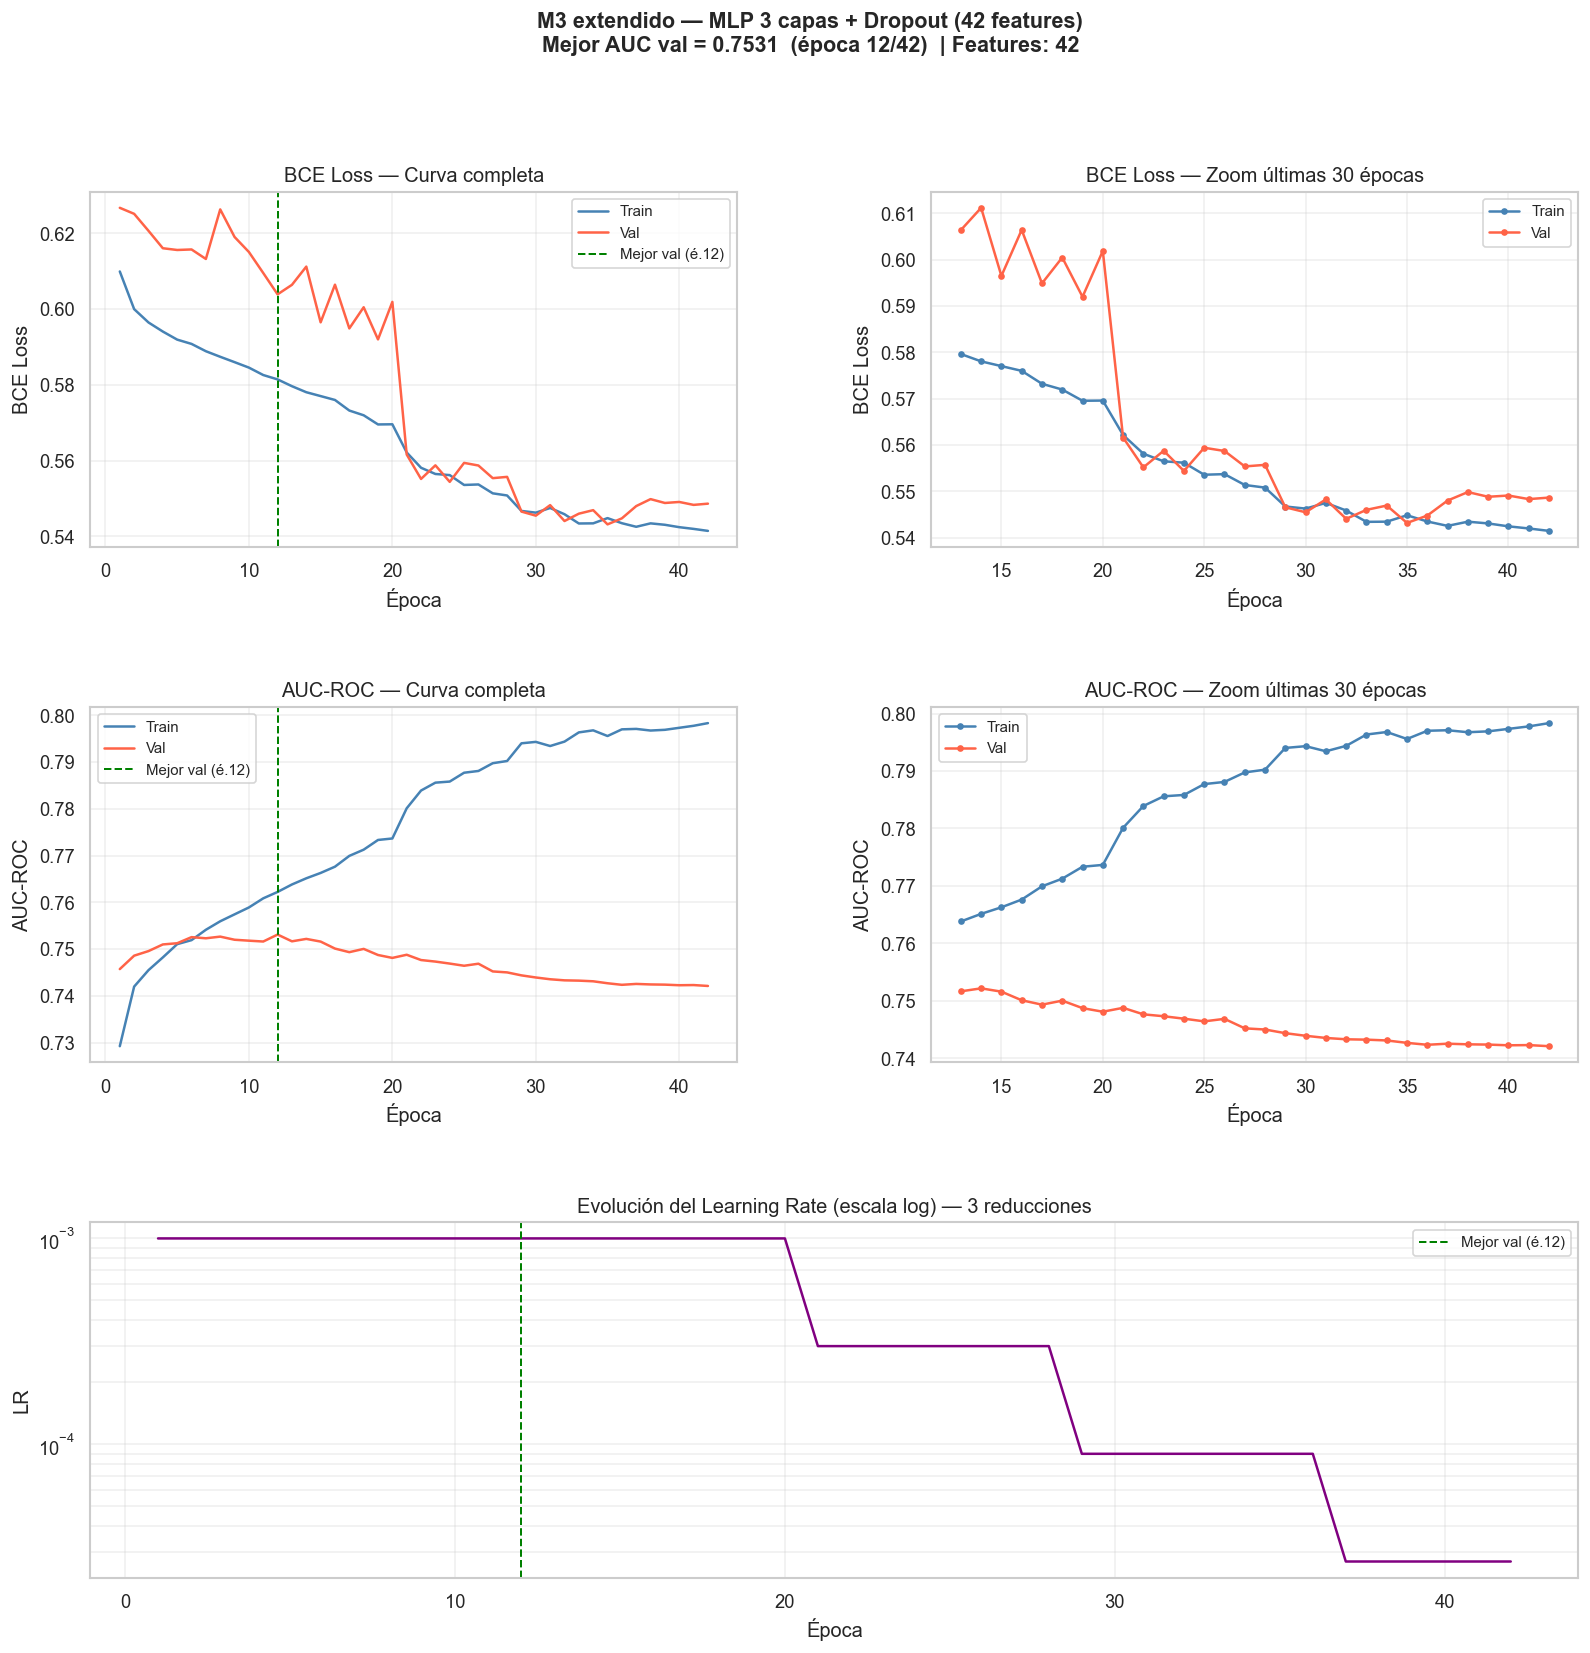

(<Figure size 1920x1800 with 5 Axes>, 0.7531001567840576, 12)

In [23]:
# Después de entrenar M3:
plot_curves_ext(history_m3_ext, 'M3 extendido — MLP 3 capas + Dropout (42 features)',
                zoom_n=30, save=True)

In [24]:
from src.custom_layers import DebtRatioLayer, ExtSourceLayer

keras.utils.set_random_seed(42)

inputs_ext = Input(shape=(N_FEATURES_EXT,), name='input')

# Rama DebtRatioLayer
debt_col  = layers.Lambda(
    lambda t: t[:, DEBT_RATIO_IDX_EXT:DEBT_RATIO_IDX_EXT + 1],
    output_shape=(1,), name='extract_debt'
)(inputs_ext)
debt_sat  = DebtRatioLayer(name='debt_saturation')(debt_col)

# Rama ExtSourceLayer
ext_start = EXT_IDXS_EXT[0]
ext_end   = EXT_IDXS_EXT[-1] + 1
ext_cols  = layers.Lambda(
    lambda t: t[:, ext_start:ext_end],
    output_shape=(3,), name='extract_ext'
)(inputs_ext)
ext_idx   = ExtSourceLayer(name='ext_source_index')(ext_cols)

# Rama densa principal (más ancha por las 42 features)
x = layers.Dense(256, activation='relu', name='dense_1')(inputs_ext)
x = layers.Dropout(0.30,                 name='dropout_1')(x)
x = layers.Dense(128, activation='relu', name='dense_2')(x)
x = layers.Dropout(0.20,                 name='dropout_2')(x)
x = layers.Dense(64,  activation='relu', name='dense_3')(x)
x = layers.Dropout(0.10,                 name='dropout_3')(x)

combined  = layers.Concatenate(name='concat')([x, debt_sat, ext_idx])
output_m6 = layers.Dense(1, activation='sigmoid', name='output')(combined)
model_m6_ext = Model(inputs_ext, output_m6, name='M6_ext')

model_m6_ext.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[AUC(name='auc')]
)
model_m6_ext.summary()

history_m6_ext = model_m6_ext.fit(
    X_tr_np, y_tr_np,
    validation_data=(X_val_np, y_val_np),
    epochs=300, batch_size=512,
    class_weight=CLASS_WEIGHT_EXT,
    callbacks=get_callbacks(patience=30),
    verbose=0
)

auc_m6_ext_val  = max(history_m6_ext.history['val_auc'])
auc_m6_ext_test = roc_auc_score(
    y_te_np, model_m6_ext.predict(X_te_np, verbose=0).ravel())

print(f"\nM6 (12 features): 0.7451  →  M6 extendido (42 features): {auc_m6_ext_test:.4f}")
print(f"Ganancia: {auc_m6_ext_test - 0.7451:+.4f}")

# Pesos aprendidos
ext_l  = model_m6_ext.get_layer('ext_source_index')
debt_l = model_m6_ext.get_layer('debt_saturation')
print(f"\nExtSourceLayer pesos: {ext_l.w.numpy()}")
print(f"DebtRatioLayer: α={debt_l.slope.numpy()[0]:.4f}, "
      f"θ={debt_l.threshold.numpy()[0]:.4f}")

Model: "M6_ext"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 42)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     11,008 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extract_debt        │ (None, 1)         │          0 │ input[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ extract_ext         │ (None, 3)         │          0 │ input[0][0]       │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ debt_saturation     │ (None, 1)         │          2 │ extract_debt[0][… │
│ (DebtRatioLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ext_source_index    │ (None, 1)         │          4 │ extract_ext[0][0] │
│ (ExtSourceLayer)    │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 66)        │          0 │ dropout_3[0][0],  │
│ (Concatenate)       │                   │            │ debt_saturation[… │
│                     │                   │            │ ext_source_index… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         67 │ concat[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 52,233 (204.04 KB)

 Trainable params: 52,233 (204.04 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.

Epoch 28: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.

Epoch 36: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 12.

M6 (12 features): 0.7451  →  M6 extendido (42 features): 0.7550
Ganancia: +0.0099

ExtSourceLayer pesos: [0.5518195 0.647044  0.738229 ]
DebtRatioLayer: α=9.9648, θ=0.3153


C:\Users\User\AppData\Local\Temp\ipykernel_9676\406388133.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  💾 report_plots/curves_ext_M6_extendido_—_Dual_Custom_+_Dropout_(42_features).pdf


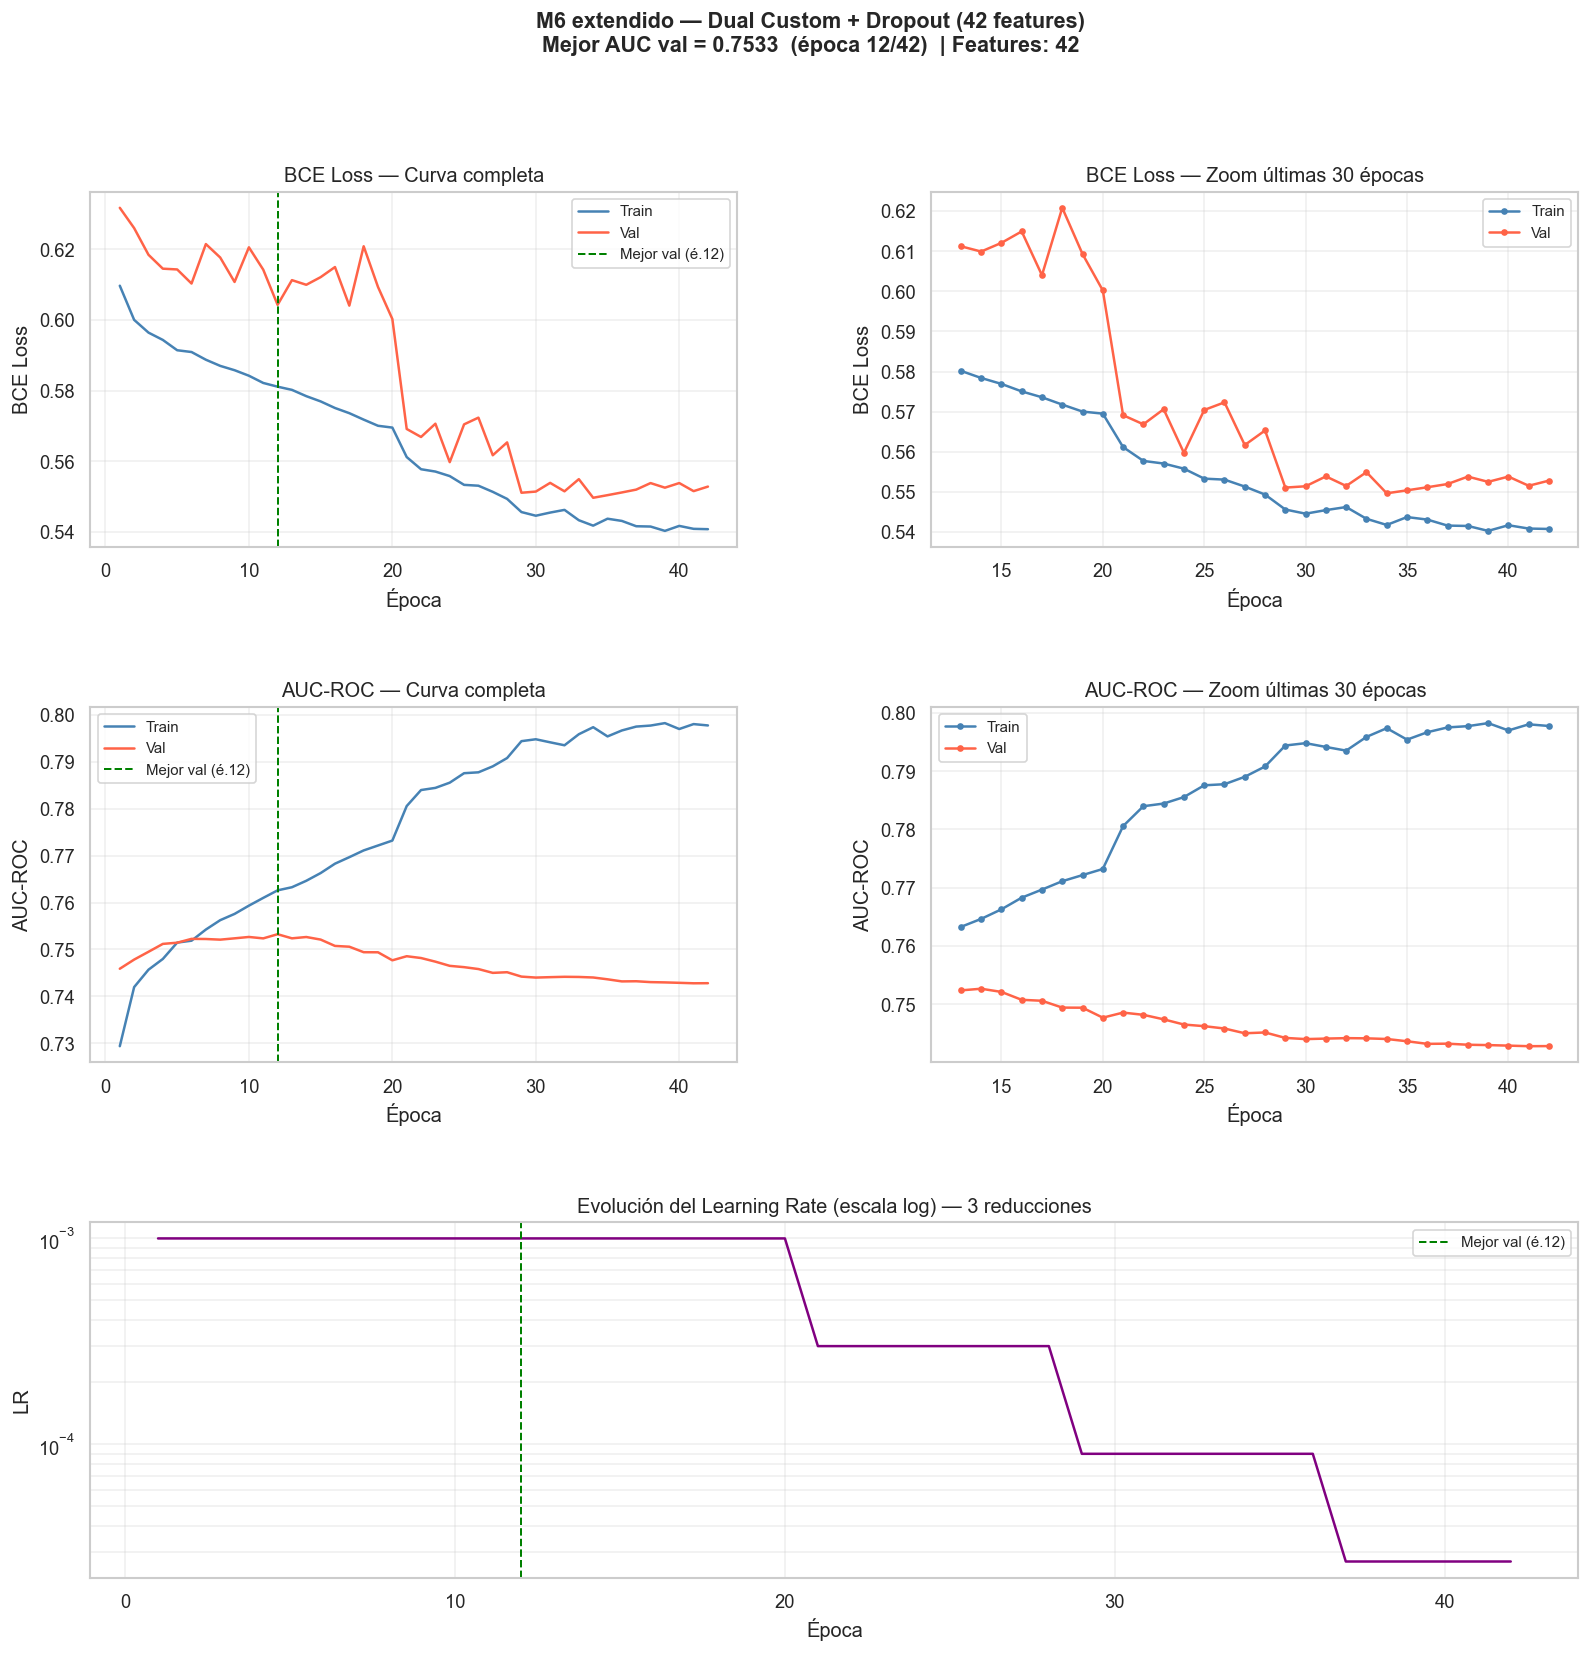

(<Figure size 1920x1800 with 5 Axes>, 0.7532521486282349, 12)

In [25]:
# Después de entrenar M6:
plot_curves_ext(history_m6_ext, 'M6 extendido — Dual Custom + Dropout (42 features)',
                zoom_n=30, save=True)

  💾 report_plots/12_extended_features_comparison.pdf


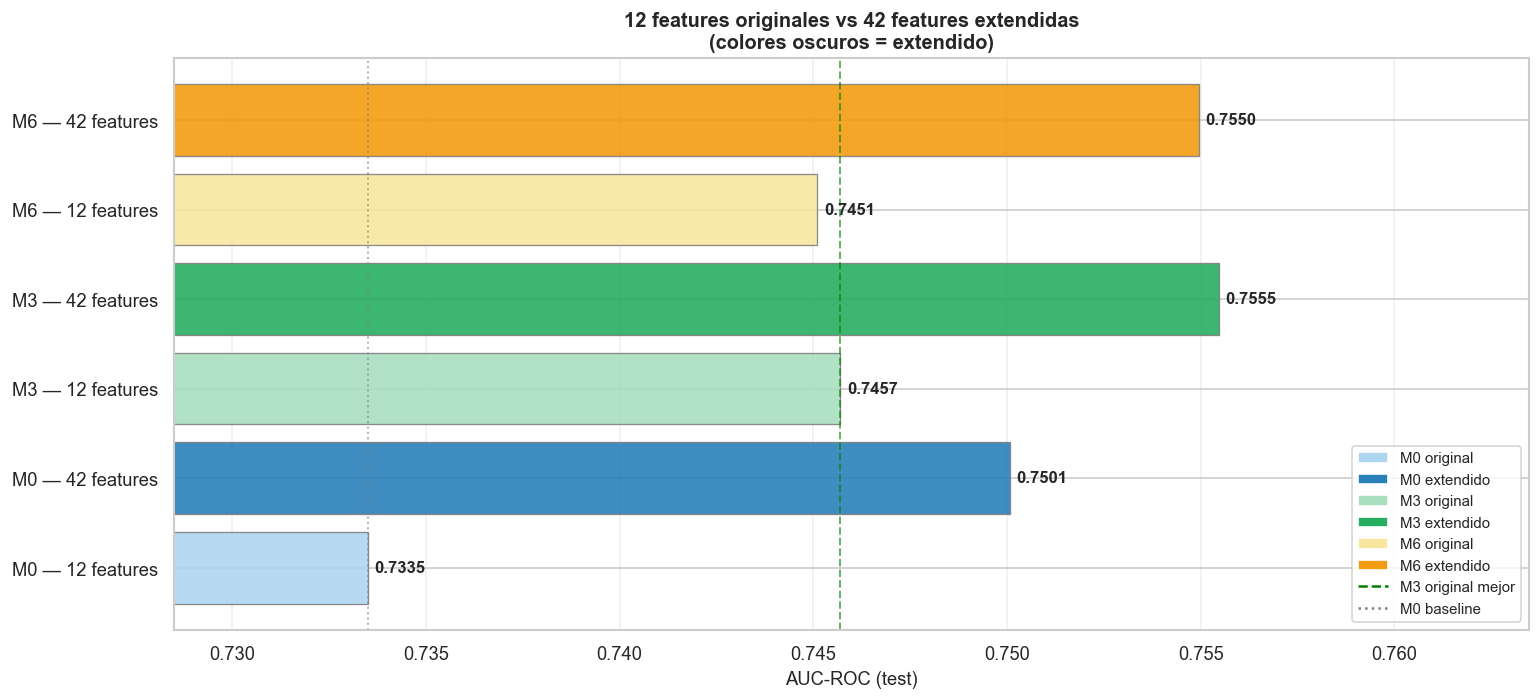

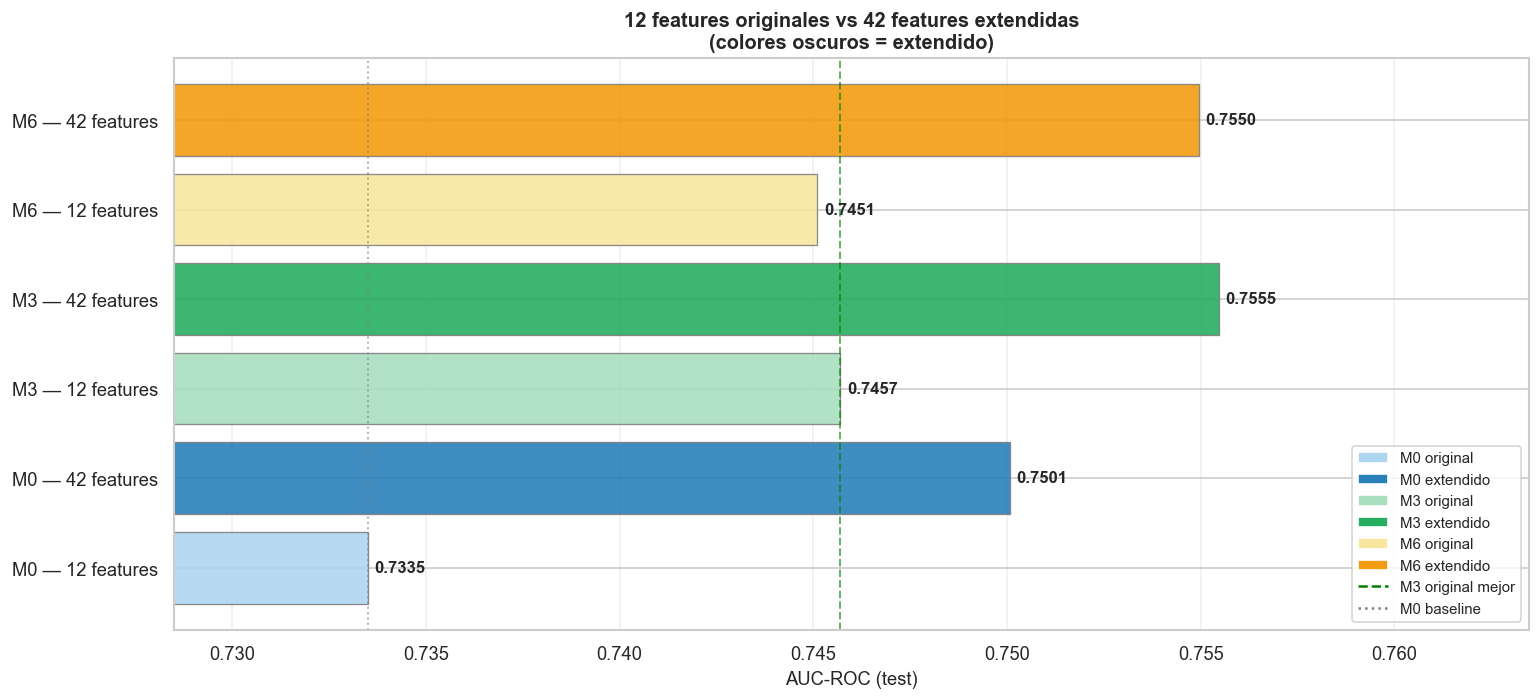

In [26]:

# Al final, tabla comparativa visual:
resultados_comp = [
    {'nombre': 'M0 — 12 features', 'n_features': 12,
     'auc_test': 0.7335, 'es_extendido': False},
    {'nombre': 'M0 — 42 features', 'n_features': 42,
     'auc_test': auc_m0_ext_test, 'es_extendido': True},
    {'nombre': 'M3 — 12 features', 'n_features': 12,
     'auc_test': 0.7457, 'es_extendido': False},
    {'nombre': 'M3 — 42 features', 'n_features': 42,
     'auc_test': auc_m3_ext_test, 'es_extendido': True},
    {'nombre': 'M6 — 12 features', 'n_features': 12,
     'auc_test': 0.7451, 'es_extendido': False},
    {'nombre': 'M6 — 42 features', 'n_features': 42,
     'auc_test': auc_m6_ext_test, 'es_extendido': True},
]
plot_comparison_bar(resultados_comp, save=True)